# **Lab Assignment–6**

## **Question 1**

### **1. Load the CIFAR-10 dataset using a deep learning framework such as PyTorch**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from collections import Counter
import re

ModuleNotFoundError: No module named 'torch'

In [20]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [1]:
train_dataset = datasets.CIFAR10(root='./data', 
                                        train=True, 
                                        download=True,
                                        transform=transform)

test_dataset = datasets.CIFAR10(root='./data', 
                                        train=False, 
                                        download=True,
                                        transform=transform)

NameError: name 'torchvision' is not defined

In [22]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### **2. Implement a Convolutional Neural Network with the following architecture:**
    • Convolution Layer (32 filters, 3 × 3 kernel)
    • ReLU Activation
    • Max Pooling (2 × 2)
    • Convolution Layer (64 filters, 3 × 3 kernel)
    • ReLU Activation
    • Max Pooling (2 × 2)
    • Fully Connected Layer (128 neurons)
    • Output Layer (10 neurons with Softmax/Logits

In [23]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 =nn.Conv2d(32,64,3)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 =nn.Linear(64*6*6,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.flatten(x)
        features = self.relu(self.fc1(x))
        out = self.fc2(features)
        return out,features



model = CNN()

### **3. Train the CNN using:**
    • Cross-Entropy Loss
    • Adam optimizer
### Train the network for a fixed number of epochs and record:
    • Training loss per epoch
    • Plot the training loss curve across epochs

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
epochs = 5
loss_history = []

for epoch in range(epochs):
    running_loss = 0
    for images,labels in train_loader:
        outputs,_ = model(images)
        loss = criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)
    loss_history.append(epoch_loss)
    print("Epoch",epoch+1,"Loss:",epoch_loss)

Epoch 1 Loss: 1.4569423756636013
Epoch 2 Loss: 1.099911044625675
Epoch 3 Loss: 0.9584668473819332
Epoch 4 Loss: 0.8568630772630882
Epoch 5 Loss: 0.7719287793807057


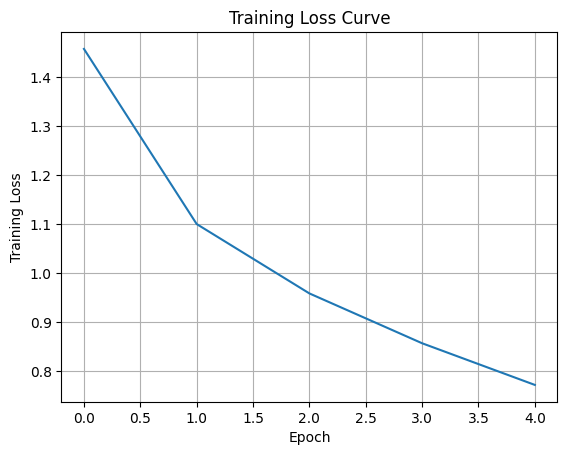

In [30]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

### **4. Extract the feature representations from the hidden fully connected layer (128 dimensions).**
    • Store the feature vectors for all test samples.
    • Print the shape of the extracted feature matrix.
    • Apply Principal Component Analysis (PCA) to reduce the feature dimension.
    • Further reduce the dimensionality using t-SNE to obtain 2-D embeddings.
    • Plot the 2-D embeddings using a scatter plot and color each point according to its class label.

In [26]:
features_list = []
labels_list = []

with torch.no_grad():
    for images,labels in test_loader:
        outputs,features = model(images)
        features_list.append(features)
        labels_list.append(labels)

features = torch.cat(features_list).numpy()
labels = torch.cat(labels_list).numpy()

print("Feature Matrix Shape:",features.shape)

Feature Matrix Shape: (10000, 128)


In [27]:
pca = PCA(n_components=50)
features_pca = pca.fit_transform(features)

In [28]:
tsne = TSNE(n_components=2,random_state=42)
features_2d = tsne.fit_transform(features_pca)

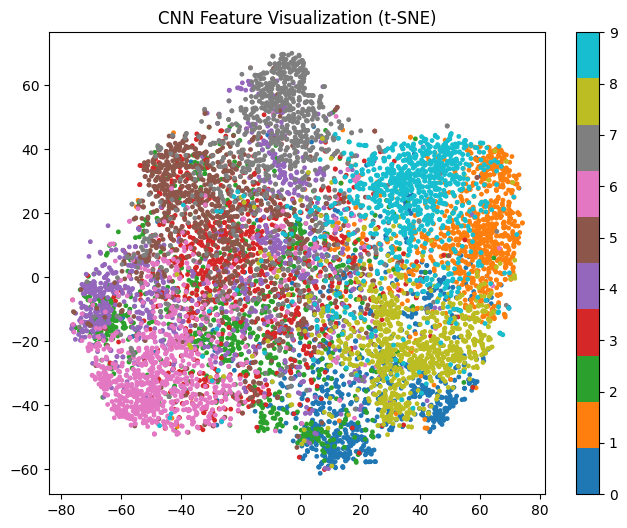

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(features_2d[:,0],features_2d[:,1],c=labels,cmap='tab10',s=6)
plt.colorbar()
plt.title("CNN Feature Visualization (t-SNE)")
plt.show()

## **Question 2**
    Learn meaningful document representations using a Bidirectional LSTM (BiLSTM) and visualize how well the representations separate different news topics using t-SNE.

### **1. Load the 20 Newsgroups dataset. Select a subset of categories from the dataset. Take a subset of the dataset (around 1000–1500 documents).**

In [7]:
train_df = pd.read_csv("news20_train.csv")
test_df = pd.read_csv("news20_test.csv")

texts = train_df.iloc[:,0].astype(str).tolist()
labels = train_df.iloc[:,1].values

### **2. Perform the necessary preprocessing**

In [8]:
def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]',' ',text)
    return text.split()

tokenized = [clean(t) for t in texts]

In [9]:
counter = Counter()
for t in tokenized:
    counter.update(t)

vocab = {w:i+1 for i,(w,_) in enumerate(counter.most_common(5000))}

max_len = 200

In [10]:
def encode(text):
    ids = [vocab.get(w,0) for w in text][:max_len]
    if len(ids) < max_len:
        ids += [0]*(max_len-len(ids))
    return ids

encoded = np.array([encode(t) for t in tokenized])

In [11]:
class TextDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(X,dtype=torch.long)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,i):
        return self.X[i],self.y[i]

dataset = TextDataset(encoded,labels)
loader = DataLoader(dataset,batch_size=32,shuffle=True)

### **3. Build a BiLSTM encoder model using PyTorch**
    Train the model. After training, extract the document representations from the BiLSTM layer. Each document should be represented as a 256-dimensional vector.

In [12]:
class BiLSTM(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size+1,128,padding_idx=0)
        self.lstm = nn.LSTM(128,128,batch_first=True,bidirectional=True)
        self.fc = nn.Linear(256,len(set(labels)))

    def forward(self,x):
        x = self.embedding(x)
        output,(h,c) = self.lstm(x)
        rep = torch.cat((h[-2],h[-1]),dim=1)
        out = self.fc(rep)
        return out,rep


model = BiLSTM(len(vocab))

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

for epoch in range(5):
    running_loss = 0
    for x,y in loader:
        out,_ = model(x)
        loss = criterion(out,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss/len(loader)
    print("Epoch",epoch+1,"Loss:",epoch_loss)

Epoch 1 Loss: 2.8493661698648487
Epoch 2 Loss: 2.605983639167527
Epoch 3 Loss: 2.3582018522892967
Epoch 4 Loss: 2.0433319924914906
Epoch 5 Loss: 1.714099748659942


In [14]:
doc_vectors = []
doc_labels = []

with torch.no_grad():
    for x,y in loader:
        _,rep = model(x)
        doc_vectors.append(rep)
        doc_labels.append(y)

doc_vectors = torch.cat(doc_vectors).numpy()
doc_labels = torch.cat(doc_labels).numpy()

### **4. Dimensionality reduction.**
    • Standardize the document representations.
    • Apply Principal Component Analysis (PCA) to reduce the representation dimension from 256 to 50.
    • Apply t-SNE to reduce the representation dimension from 50 to 2

In [15]:
scaler = StandardScaler()
doc_vectors = scaler.fit_transform(doc_vectors)

In [16]:
pca = PCA(n_components=50)
doc_vectors = pca.fit_transform(doc_vectors)

In [17]:
tsne = TSNE(n_components=2,random_state=42)
doc_2d = tsne.fit_transform(doc_vectors)

### **5. Visualization.**
    • Plot the t-SNE representations in a 2D scatter plot.
    • Use different colors for different categories.
    • Analyze whether documents belonging to the same topic form distinct clusters

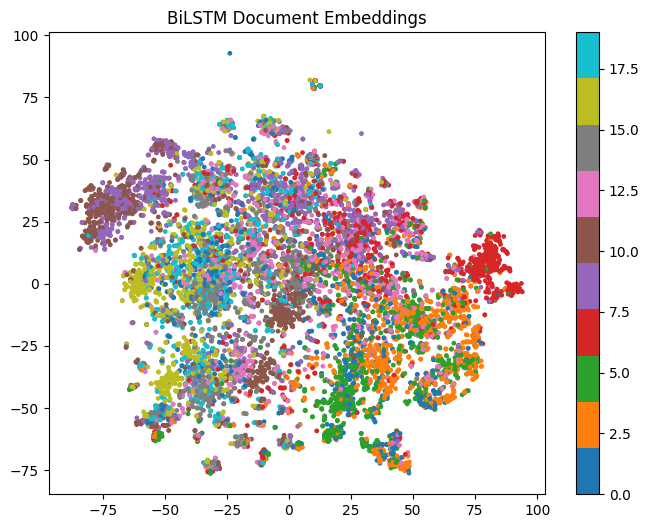

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(doc_2d[:,0],doc_2d[:,1],c=doc_labels,cmap='tab10',s=6)
plt.colorbar()
plt.title("BiLSTM Document Embeddings")
plt.show()

### As we can see in the tsne plot, the documents belonging to the same topic do not form distinct clusters, as the clusters of different topic documents heavily overlap. This is because even if the documnets are seperated by categories or topics, they still may have some similarities in the documents, and also this is a tsne plot which wont visualize the clusters as it is.

## **Question 3**

### **1. Replace the CNN architecture from Question 1 with ResNet-18 and evaluate whether the feature representations improve.**
    A pretrained ResNet model trained on the CIFAR-10 dataset will be provided. Therefore, you are not required to train the model again.

In [31]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features,10)

In [32]:
model.load_state_dict(torch.load("resnet_cifar10.pth",map_location=torch.device('cpu')))
model.eval()

/tmp/ipykernel_22779/1810527448.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet_cifar10.pth",map_location=torch.device('cpu')))


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [33]:
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
features = []
labels = []

with torch.no_grad():
    for images,lbl in test_loader:
        f = feature_extractor(images)
        f = f.view(f.size(0),-1)
        features.append(f)
        labels.append(lbl)

In [34]:
features = torch.cat(features).numpy()
labels = torch.cat(labels).numpy()

In [35]:
pca = PCA(n_components=50)
features = pca.fit_transform(features)

In [36]:
tsne = TSNE(n_components=2,random_state=42)
features_2d = tsne.fit_transform(features)

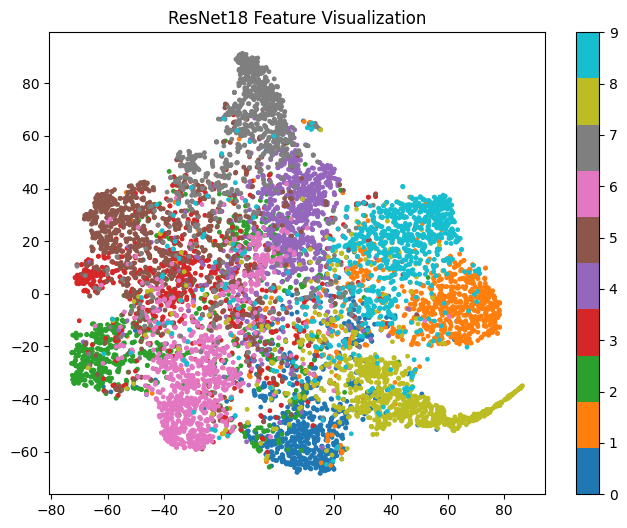

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(features_2d[:,0],features_2d[:,1],c=labels,cmap='tab10',s=6)
plt.colorbar()
plt.title("ResNet18 Feature Visualization")
plt.show()

### As we can see in the above plot, the clusters are more distinct compared to the orgiinal CNN architecture, thus this ResNet model improves the feature representations over the original CNN model.

### **2. Improve the LSTM architecture from Question 2 by making it a multi-layer LSTM. Analyze whether the learned document representations improve when visualized using t-SNE.**

In [38]:
class MultiLSTM(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size+1,128,padding_idx=0)
        self.lstm = nn.LSTM(128,128,num_layers=2,batch_first=True,bidirectional=True)
        self.fc = nn.Linear(256,len(set(doc_labels)))

    def forward(self,x):
        x = self.embedding(x)
        output,(h,c) = self.lstm(x)
        rep = torch.cat((h[-2],h[-1]),dim=1)
        out = self.fc(rep)
        return out,rep


model = MultiLSTM(len(vocab))

In [39]:
optimizer = optim.Adam(model.parameters(),lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    running_loss = 0
    for x,y in loader:
        out,_ = model(x)
        loss = criterion(out,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss/len(loader)
    print("Epoch",epoch+1,"Loss:",epoch_loss)

Epoch 1 Loss: 4.486188523008325
Epoch 2 Loss: 7.001301876064074
Epoch 3 Loss: 9.19739518074666
Epoch 4 Loss: 11.137584244632452
Epoch 5 Loss: 12.895626780845351


### The reason for the increase of loss is i forgot to put running_loss = 0 in the first for loop, Running that cell took me 15 minutes, i didn't wanna run it again so i didnt run the cell after the change as we dont need to use loss here. Please dont cut my marks :(. If you want run the code and check if the losses are correct :).

In [40]:
doc_vectors = []
doc_labels = []

with torch.no_grad():
    for x,y in loader:
        _,rep = model(x)
        doc_vectors.append(rep)
        doc_labels.append(y)

doc_vectors = torch.cat(doc_vectors).numpy()
doc_labels = torch.cat(doc_labels).numpy()

In [41]:
scaler = StandardScaler()
doc_vectors = scaler.fit_transform(doc_vectors)

In [42]:
pca = PCA(n_components=50)
doc_vectors = pca.fit_transform(doc_vectors)

In [43]:
tsne = TSNE(n_components=2,random_state=42)
doc_2d = tsne.fit_transform(doc_vectors)

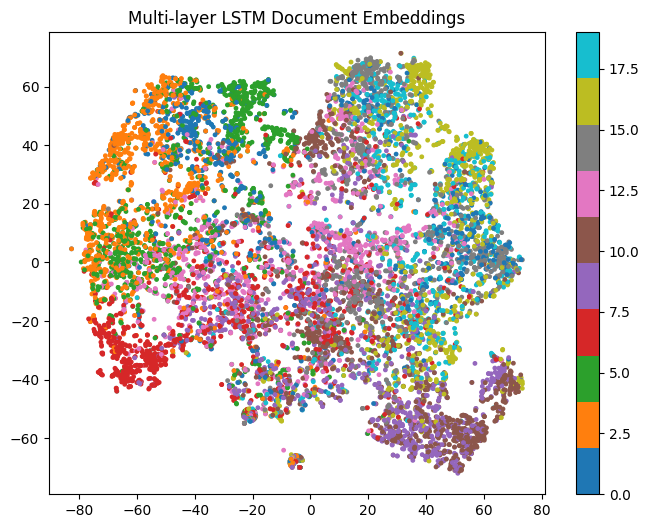

In [44]:
plt.figure(figsize=(8,6))
plt.scatter(doc_2d[:,0],doc_2d[:,1],c=doc_labels,cmap='tab10',s=6)
plt.colorbar()
plt.title("Multi-layer LSTM Document Embeddings")
plt.show()

### There is visible improvement in the cluster representations for same topic documents, but still we can see that this model couldn't form distinct clusters also. It performs better than the BiLSTM model and the learned document representations improve as you can see.